# Multi-Trial Structure and Heterogeneity

We now move from single-trial validation to a multi-trial setting.

Even when IPD is perfectly reconstructed, combining data across trials introduces new challenges:
- each trial represents a different population
- treatment effects vary across trials
- naive pooling does not yield a well-defined causal estimand

This notebook explores these issues empirically.

In [1]:
# Simulate multiple trials
from src.simulation.trial_generator import simulate_multi_trial

multi = simulate_multi_trial(n_trials=4, n_per_trial=250, seed=733)
df_multi = multi.ipd

df_multi.head()

,age,biomarker,stage,treatment,time,event,trial_id
0,67.106302,1,2,0,1.778858,1,trial_001
1,55.792886,0,2,0,24.000000,0,trial_001
2,55.350177,0,3,0,0.116891,1,trial_001
3,60.424046,1,1,1,0.889068,0,trial_001
4,55.414515,0,1,1,3.516167,1,trial_001


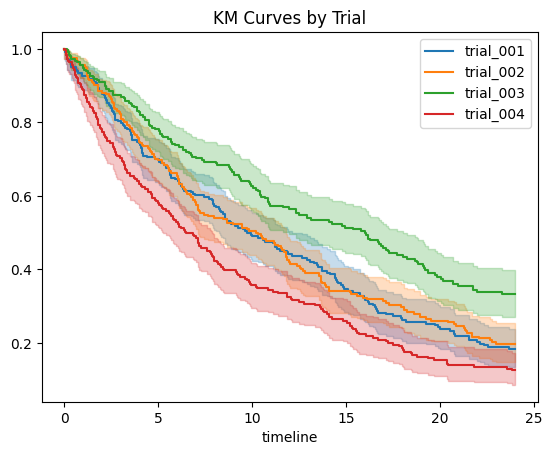

In [2]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

for trial_id, g in df_multi.groupby("trial_id"):
    kmf = KaplanMeierFitter()
    kmf.fit(g["time"], g["event"], label=trial_id)
    kmf.plot()

plt.title("KM Curves by Trial")
plt.show()

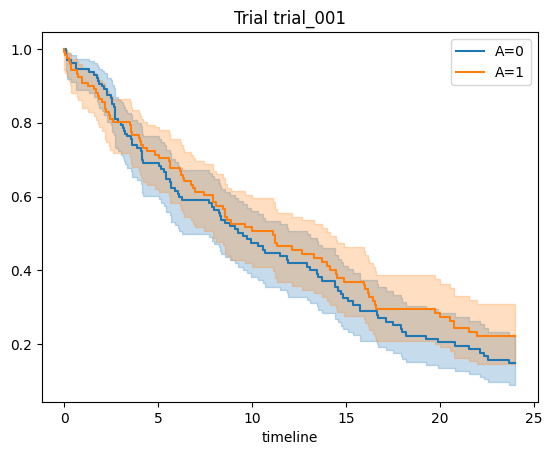

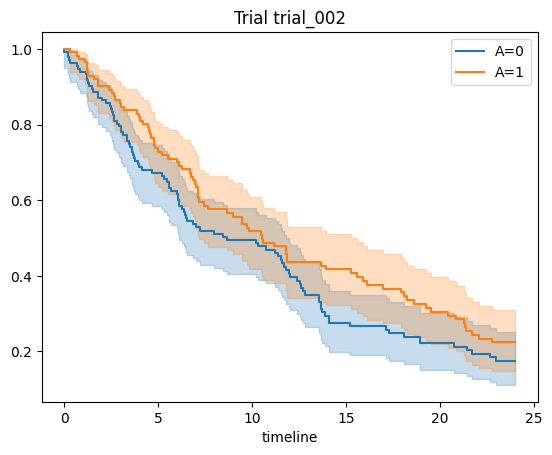

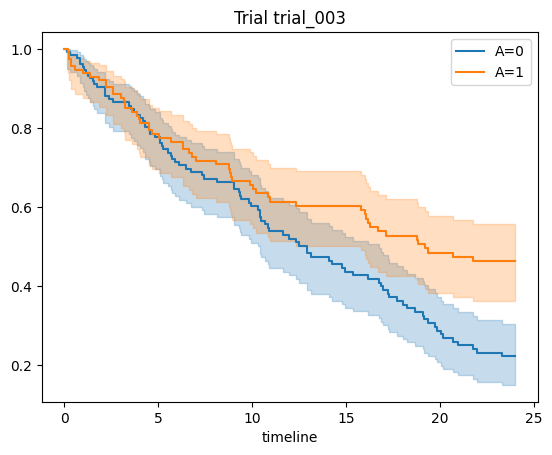

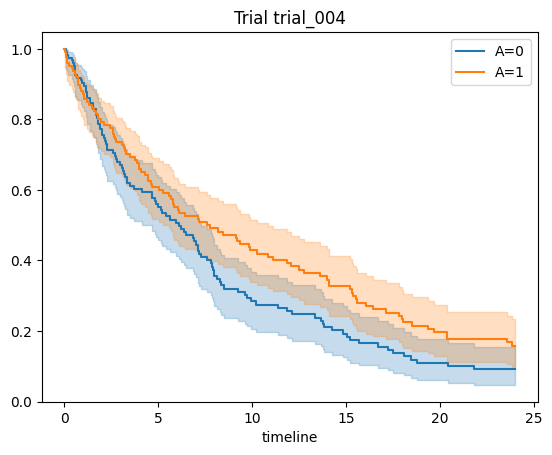

In [3]:
for trial_id, g in df_multi.groupby("trial_id"):
    plt.figure()
    for a in [0, 1]:
        sub = g[g["treatment"] == a]
        kmf = KaplanMeierFitter()
        kmf.fit(sub["time"], sub["event"], label=f"A={a}")
        kmf.plot()

    plt.title(f"Trial {trial_id}")
    plt.show()

In [4]:
# Trial Level Survival Differences
from src.causal.estimands import trial_level_survival_difference

trial_effects = trial_level_survival_difference(df_multi, t0=12.0)
trial_effects

,trial_id,t0,S0,S1,Delta
0,trial_001,12.0,0.419429,0.465178,0.045749
1,trial_002,12.0,0.405150,0.437186,0.032036
2,trial_003,12.0,0.520899,0.614308,0.093410
3,trial_004,12.0,0.256523,0.392497,0.135974


In [5]:
# Pooled
from src.causal.estimands import pooled_survival_difference

pooled = pooled_survival_difference(df_multi, t0=12.0)
pooled

,t0,S0,S1,Delta
0,12.0,0.403394,0.474549,0.071155


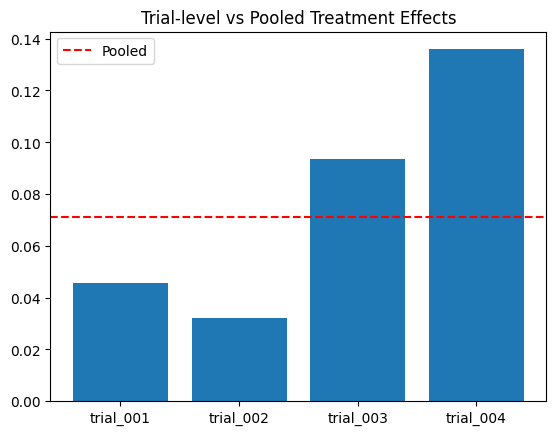

In [6]:
import matplotlib.pyplot as plt

plt.bar(trial_effects["trial_id"], trial_effects["Delta"])
plt.axhline(pooled["Delta"].iloc[0], linestyle="--", color="red", label="Pooled")
plt.legend()
plt.title("Trial-level vs Pooled Treatment Effects")
plt.show()

In [7]:
covariates = ["age", "biomarker", "stage"]

df_multi.groupby("trial_id")[covariates].mean()

,age,biomarker,stage
trial_id,,,
trial_001,60.596765,0.400,1.636
trial_002,56.125191,0.576,1.848
trial_003,58.726448,0.608,1.740
trial_004,53.194751,0.536,1.664


## Covariate Heterogeneity Across Trials

The baseline covariate distributions differ across trials, as shown by the variation in mean age, biomarker prevalence, and disease stage.

In particular:
- Mean age varies across trials (approximately 53 to 61)
- Biomarker prevalence ranges from 0.40 to 0.61
- Average stage also differs across trials

These differences indicate that each trial samples from a **distinct underlying population**.

---

## Implications

Because survival outcomes depend on baseline covariates, these differences induce:
- variation in baseline survival across trials  
- heterogeneity in treatment effects  

As a result, pooling data across trials without adjustment combines observations from **non-comparable populations**.

---

## Key Takeaway

Even with perfectly reconstructed IPD, the presence of covariate heterogeneity implies that:
- trial-specific estimates correspond to different target populations  
- pooled estimates reflect a mixture of these populations  

This reinforces the need for methods that adjust for cross-trial differences and define a common target population for causal inference.